# Simple Linear Regression: Exploring Salary vs Experience

I'm exploring one of the most fundamental questions in machine learning: **can we predict salary based on years of experience?** 

This notebook walks through building a simple linear regression model to understand the relationship between these two variables. I'll be looking at how well a straight line can capture this relationship and what the evaluation metrics tell us about our model's performance.

**What I'm exploring:**
- Loading and examining the salary-experience dataset
- Building a linear regression model from scratch using scikit-learn
- Evaluating model performance with multiple metrics (MSE, RMSE, MAE, R²)
- Visualizing the results on both training and test data

This is a great starting point for understanding supervised learning fundamentals!

In [1]:
# Importing Python libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



In [3]:
# Loading the dataset into a pandas dataframe

df = pd.read_csv(r'C:\Users\tm0792.STUDENTS.008\OneDrive - UNT System\Academics\Second Sem\DTSC 5505 - Applied ML for Data Scientists\Data_Science-Projects\ml-algos\data\Simple-Linear-Dataset.csv')
df.head()

,Years_of_Expertise,Salary
0,1.1,39343
1,1.3,46205
2,1.5,37731
3,2.0,43525
4,2.2,39891


In [4]:
# Calculating Descriptive statistics 

df.describe()

,Years_of_Expertise,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


In [5]:
# Loading the values into X and y

X = df.iloc[:, :-1].values
y = df.iloc[:, 1].values

print(y)


[ 39343  46205  37731  43525  39891  56642  60150  54445  64445  57189
  63218  55794  56957  57081  61111  67938  66029  83088  81363  93940
  91738  98273 101302 113812 109431 105582 116969 112635 122391 121872]


In [6]:
# Splitting the dataset into the Training set and Test set

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, random_state=0)

print(X_train, X_test, y_train, y_test)

[[ 2.9]
 [ 5.1]
 [ 3.2]
 [ 4.5]
 [ 8.2]
 [ 6.8]
 [ 1.3]
 [10.5]
 [ 3. ]
 [ 2.2]
 [ 5.9]
 [ 6. ]
 [ 3.7]
 [ 3.2]
 [ 9. ]
 [ 2. ]
 [ 1.1]
 [ 7.1]
 [ 4.9]
 [ 4. ]] [[ 1.5]
 [10.3]
 [ 4.1]
 [ 3.9]
 [ 9.5]
 [ 8.7]
 [ 9.6]
 [ 4. ]
 [ 5.3]
 [ 7.9]] [ 56642  66029  64445  61111 113812  91738  46205 121872  60150  39891
  81363  93940  57189  54445 105582  43525  39343  98273  67938  56957] [ 37731 122391  57081  63218 116969 109431 112635  55794  83088 101302]


In [7]:
# Feature scaling

# from sklearn.preprocessing import StandardScaler
# sc_X = StandardScaler()
# X_train = sc_X.fit_transform(X_train)
# X_test = sc_X.transform(X_test)

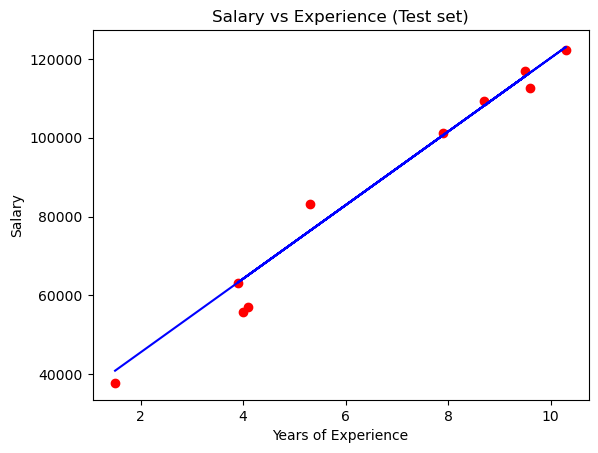

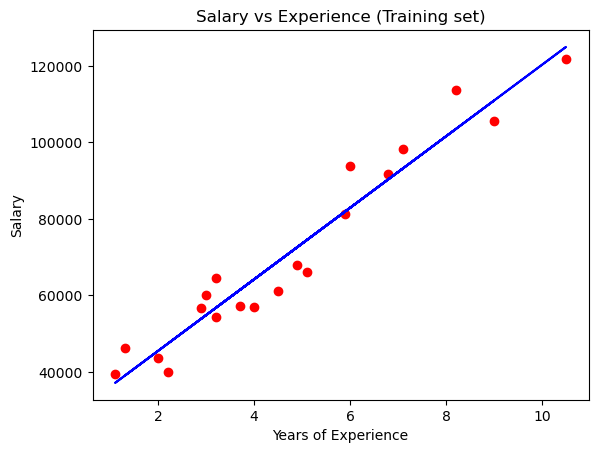

In [8]:
# Fitting Simple Linear Regression to the Training set
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()

# Train the model on the training dataset
regressor.fit(X_train, y_train)

# Predicting the Test set results
y_pred = regressor.predict(X_test)

# Visualising the Test set results
plt.scatter(X_test, y_test, color='red')
plt.plot(X_test, regressor.predict(X_test), color='blue')
plt.title('Salary vs Experience (Test set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()

# Visualising the Training set results
plt.scatter(X_train, y_train, color='red')
plt.plot(X_train, regressor.predict(X_train), color='blue')
plt.title('Salary vs Experience (Training set)')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.show()



In [9]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Evaluate the model on the training set
y_train_pred = regressor.predict(X_train)
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

print("Training set evaluation:")
print(f"Mean Squared Error (MSE): {mse_train}")
print(f"Root Mean Squared Error (RMSE): {rmse_train}")
print(f"Mean Absolute Error (MAE): {mae_train}")
print(f"R-squared (R2): {r2_train}")

# Evaluate the model on the test set
mse_test = mean_squared_error(y_test, y_pred)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test, y_pred)
r2_test = r2_score(y_test, y_pred)

print("\nTest set evaluation:")
print(f"Mean Squared Error (MSE): {mse_test}")
print(f"Root Mean Squared Error (RMSE): {rmse_test}")
print(f"Mean Absolute Error (MAE): {mae_test}")
print(f"R-squared (R2): {r2_test}")


Training set evaluation:
Mean Squared Error (MSE): 36852948.76438455
Root Mean Squared Error (RMSE): 6070.662959214961
Mean Absolute Error (MAE): 5310.294905607346
R-squared (R2): 0.9381900012894278

Test set evaluation:
Mean Squared Error (MSE): 21026037.329511296
Root Mean Squared Error (RMSE): 4585.4157204675885
Mean Absolute Error (MAE): 3426.4269374307123
R-squared (R2): 0.9749154407708353


# Multiple Linear Regression: Understanding Business Profitability

I'm exploring a more complex question: **what factors drive business profitability?** Unlike simple linear regression with one variable, I now have multiple features that could influence profit.

This notebook analyzes a business dataset with investments in three different products across various locations. I'll build multiple linear regression models to understand which factors matter most for maximizing profit.

**What I'm exploring:**
- Handling categorical variables (location) with encoding techniques
- Building models with different feature combinations
- Using backward elimination to find the most significant predictors
- Comparing model performance across different feature sets
- Understanding the dummy variable trap and multicollinearity

**Three different approaches:**
1. **All features**: Product_1, Product_2, Product_3, and Location
2. **Product_3 + Location**: Focusing on one product and geographic factors
3. **Product_1 + Product_3**: Comparing two product investments

This helps me understand how multiple variables work together to predict outcomes!

In [10]:
df02 = pd.read_csv(r'C:\Users\tm0792.STUDENTS.008\OneDrive - UNT System\Academics\Second Sem\DTSC 5505 - Applied ML for Data Scientists\Data_Science-Projects\ml-algos\data\Multiple-Linear-Dataset.csv')
df02.head()


,Product_1,Product_2,Product_3,Location,Profit
0,165349.20,136897.80,471784.10,City_1,192261.83
1,162597.70,151377.59,443898.53,City_2,191792.06
2,153441.51,101145.55,407934.54,City_3,191050.39
3,144372.41,118671.85,383199.62,City_1,182901.99
4,142107.34,91391.77,366168.42,City_3,166187.94


In [11]:
df02.describe()

,Product_1,Product_2,Product_3,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


#### Model 1 - All the variables except profit are taken as Input. Profit is taken as output

In [12]:
# Loading the values into X and y

X = df02.iloc[:, :-1].values
y = df02.iloc[:, 4].values

#print(X)


In [13]:
# Import necessary libraries
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

#Encoding the categorical column at index 3 using LabelEncoder
labelencoder_X = LabelEncoder()
X[:, 3] = labelencoder_X.fit_transform(X[:, 3])

column_transformer = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(), [3])  
    ],
    remainder='passthrough'  
)

X = column_transformer.fit_transform(X)

# Avoiding the Dummy Variable Trap - avoiding multicollinearity
X = X[:, 1:]  

X = np.nan_to_num(X)
y = np.nan_to_num(y)
X = X.astype(float)
y = y.astype(float)

In [14]:
# Splitting the dataset into the Training set and Test set

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [15]:
from sklearn.linear_model import LinearRegression

# Creating the regressor and fitting it to the training data
regressor = LinearRegression()
regressor.fit(X_train, y_train)

# Predicting the Test set results

y_pred = regressor.predict(X_test)



# Building the optimal model using Backward Elimination

import statsmodels.api as sm  # Updated import statement for statsmodels

# Adding a column of ones for the intercept term
X = np.append(arr=np.ones((50, 1)).astype(int), values=X, axis=1)

#print(X)

# Stepwise backward elimination - OLS - Ordinary Least Squares
X_opt = X[:, [0, 1, 2, 3, 4, 5]]
regressor_OLS = sm.OLS(endog=y, exog=X_opt).fit()
regressor_OLS.summary()
print(X_opt)

X_opt = X[:, [0, 1, 3, 4, 5]]
regressor_OLS = sm.OLS(endog=y, exog=X_opt).fit()
regressor_OLS.summary()

X_opt = X[:, [0, 3, 4, 5]]
regressor_OLS = sm.OLS(endog=y, exog=X_opt).fit()
regressor_OLS.summary()

X_opt = X[:, [0, 3, 5]]
regressor_OLS = sm.OLS(endog=y, exog=X_opt).fit()
regressor_OLS.summary()

X_opt = X[:, [0, 3]]
regressor_OLS = sm.OLS(endog=y, exog=X_opt).fit()
regressor_OLS.summary()


[[1.0000000e+00 0.0000000e+00 0.0000000e+00 1.6534920e+05 1.3689780e+05
  4.7178410e+05]
 [1.0000000e+00 1.0000000e+00 0.0000000e+00 1.6259770e+05 1.5137759e+05
  4.4389853e+05]
 [1.0000000e+00 0.0000000e+00 1.0000000e+00 1.5344151e+05 1.0114555e+05
  4.0793454e+05]
 [1.0000000e+00 0.0000000e+00 0.0000000e+00 1.4437241e+05 1.1867185e+05
  3.8319962e+05]
 [1.0000000e+00 0.0000000e+00 1.0000000e+00 1.4210734e+05 9.1391770e+04
  3.6616842e+05]
 [1.0000000e+00 0.0000000e+00 0.0000000e+00 1.3187690e+05 9.9814710e+04
  3.6286136e+05]
 [1.0000000e+00 1.0000000e+00 0.0000000e+00 1.3461546e+05 1.4719887e+05
  1.2771682e+05]
 [1.0000000e+00 0.0000000e+00 1.0000000e+00 1.3029813e+05 1.4553006e+05
  3.2387668e+05]
 [1.0000000e+00 0.0000000e+00 0.0000000e+00 1.2054252e+05 1.4871895e+05
  3.1161329e+05]
 [1.0000000e+00 1.0000000e+00 0.0000000e+00 1.2333488e+05 1.0867917e+05
  3.0498162e+05]
 [1.0000000e+00 0.0000000e+00 1.0000000e+00 1.0191308e+05 1.1059411e+05
  2.2916095e+05]
 [1.0000000e+00 1.000

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.947
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                     849.8
Date:                Wed, 27 Aug 2025   Prob (F-statistic):           3.50e-32
Time:                        18:10:41   Log-Likelihood:                -527.44
No. Observations:                  50   AIC:                             1059.
Df Residuals:                      48   BIC:                             1063.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.903e+04   2537.897     19.320      0.000    4.39e+04    5.41e+04
x1             0.8543      0.029     29.151      0.000       0.795       0.913
==============================================================================
Omnibus:                       13.727   Durbin-Watson:                   1.116
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               18.536
Skew:                          -0.911   Prob(JB):                     9.44e-05
Kurtosis:                       5.361   Cond. No.                     1.65e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.65e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Mean Squared Error: 83502864.03
Root Mean Squared Error: 9137.99
R-squared: 0.93


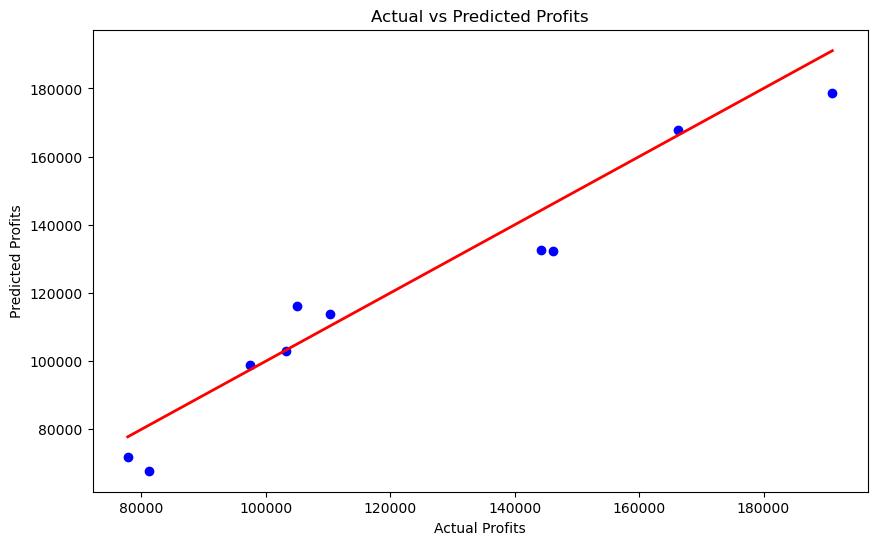

In [16]:
# Evaluating the model

# 1. Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")

# 2. Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error: {rmse:.2f}")

# 3. R-squared (R2 Score)
r2 = r2_score(y_test, y_pred)
print(f"R-squared: {r2:.2f}")

# Visualizing the Results

# Visualizing predictions vs actual values for the test set
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)
plt.title('Actual vs Predicted Profits')
plt.xlabel('Actual Profits')
plt.ylabel('Predicted Profits')
plt.show()



#### Model 2 - Product 3 and location are taken as Input. Profit is taken as output

In [17]:

X1 = df02.iloc[:, -3:-1].values
y1 = df02.iloc[:, 4].values

print(X1)


[[471784.1 'City_1']
 [443898.53 'City_2']
 [407934.54 'City_3']
 [383199.62 'City_1']
 [366168.42 'City_3']
 [362861.36 'City_1']
 [127716.82 'City_2']
 [323876.68 'City_3']
 [311613.29 'City_1']
 [304981.62 'City_2']
 [229160.95 'City_3']
 [249744.55 'City_2']
 [249839.44 'City_3']
 [252664.93 'City_2']
 [256512.92 'City_3']
 [261776.23 'City_1']
 [264346.06 'City_2']
 [282574.31 'City_1']
 [294919.57 'City_3']
 [0.0 'City_1']
 [298664.47 'City_2']
 [299737.29 'City_1']
 [303319.26 'City_3']
 [304768.73 'City_3']
 [140574.81 'City_1']
 [137962.62 'City_2']
 [134050.07 'City_3']
 [353183.81 'City_1']
 [118148.2 'City_3']
 [107138.38 'City_1']
 [91131.24 'City_3']
 [88218.23 'City_1']
 [46085.25 'City_2']
 [214634.81 'City_3']
 [210797.67 'City_2']
 [205517.64 'City_1']
 [201126.82 'City_3']
 [197029.42 'City_2']
 [185265.1 'City_1']
 [174999.3 'City_2']
 [172795.67 'City_2']
 [164470.71 'City_3']
 [148001.11 'City_2']
 [35534.17 'City_1']
 [28334.72 'City_2']
 [1903.93 'City_1']
 [297

In [18]:
# Import necessary libraries
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

#Encoding the categorical column at index 3 using LabelEncoder
labelencoder_X1 = LabelEncoder()
X1[:, 1] = labelencoder_X1.fit_transform(X1[:, 1])

#print(X1)

column_transformer = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(), [1])  
    ],
    remainder='passthrough'  
)


X1 = column_transformer.fit_transform(X1)
#print(X1)

# Avoiding the Dummy Variable Trap - avoiding multicollinearity
X1 = X1[:, 1:]  

print(X1)
X1 = np.nan_to_num(X1)
y1 = np.nan_to_num(y1)
X1 = X1.astype(float)
y1 = y1.astype(float)



[[0.0 0.0 471784.1]
 [1.0 0.0 443898.53]
 [0.0 1.0 407934.54]
 [0.0 0.0 383199.62]
 [0.0 1.0 366168.42]
 [0.0 0.0 362861.36]
 [1.0 0.0 127716.82]
 [0.0 1.0 323876.68]
 [0.0 0.0 311613.29]
 [1.0 0.0 304981.62]
 [0.0 1.0 229160.95]
 [1.0 0.0 249744.55]
 [0.0 1.0 249839.44]
 [1.0 0.0 252664.93]
 [0.0 1.0 256512.92]
 [0.0 0.0 261776.23]
 [1.0 0.0 264346.06]
 [0.0 0.0 282574.31]
 [0.0 1.0 294919.57]
 [0.0 0.0 0.0]
 [1.0 0.0 298664.47]
 [0.0 0.0 299737.29]
 [0.0 1.0 303319.26]
 [0.0 1.0 304768.73]
 [0.0 0.0 140574.81]
 [1.0 0.0 137962.62]
 [0.0 1.0 134050.07]
 [0.0 0.0 353183.81]
 [0.0 1.0 118148.2]
 [0.0 0.0 107138.38]
 [0.0 1.0 91131.24]
 [0.0 0.0 88218.23]
 [1.0 0.0 46085.25]
 [0.0 1.0 214634.81]
 [1.0 0.0 210797.67]
 [0.0 0.0 205517.64]
 [0.0 1.0 201126.82]
 [1.0 0.0 197029.42]
 [0.0 0.0 185265.1]
 [1.0 0.0 174999.3]
 [1.0 0.0 172795.67]
 [0.0 1.0 164470.71]
 [1.0 0.0 148001.11]
 [0.0 0.0 35534.17]
 [1.0 0.0 28334.72]
 [0.0 0.0 1903.93]
 [0.0 1.0 297114.46]
 [1.0 0.0 0.0]
 [0.0 0.0 0.0]


In [19]:
# Splitting the dataset into the Training set and Test set

X_train, X_test, y_train, y_test = train_test_split(X1, y1, test_size=0.2, random_state=0)

In [20]:
from sklearn.linear_model import LinearRegression

# Creating the regressor and fitting it to the training data
regressor = LinearRegression()
regressor.fit(X_train, y_train)

# Predicting the Test set results

y_pred = regressor.predict(X_test)



# Building the optimal model using Backward Elimination

import statsmodels.api as sm  # Updated import statement for statsmodels

# Adding a column of ones for the intercept term
X1 = np.append(arr=np.ones((50, 1)).astype(int), values=X1, axis=1)

print(X1)

# Stepwise backward elimination - OLS - Ordinary Least Squares
X_opt = X1[:, [0, 1, 2, 3]]
regressor_OLS = sm.OLS(endog=y, exog=X_opt).fit()
regressor_OLS.summary()
print(X_opt)

X_opt = X1[:, [0, 1, 2]]
regressor_OLS = sm.OLS(endog=y, exog=X_opt).fit()
regressor_OLS.summary()

X_opt = X1[:, [0, 1]]
regressor_OLS = sm.OLS(endog=y, exog=X_opt).fit()
regressor_OLS.summary()


[[1.0000000e+00 0.0000000e+00 0.0000000e+00 4.7178410e+05]
 [1.0000000e+00 1.0000000e+00 0.0000000e+00 4.4389853e+05]
 [1.0000000e+00 0.0000000e+00 1.0000000e+00 4.0793454e+05]
 [1.0000000e+00 0.0000000e+00 0.0000000e+00 3.8319962e+05]
 [1.0000000e+00 0.0000000e+00 1.0000000e+00 3.6616842e+05]
 [1.0000000e+00 0.0000000e+00 0.0000000e+00 3.6286136e+05]
 [1.0000000e+00 1.0000000e+00 0.0000000e+00 1.2771682e+05]
 [1.0000000e+00 0.0000000e+00 1.0000000e+00 3.2387668e+05]
 [1.0000000e+00 0.0000000e+00 0.0000000e+00 3.1161329e+05]
 [1.0000000e+00 1.0000000e+00 0.0000000e+00 3.0498162e+05]
 [1.0000000e+00 0.0000000e+00 1.0000000e+00 2.2916095e+05]
 [1.0000000e+00 1.0000000e+00 0.0000000e+00 2.4974455e+05]
 [1.0000000e+00 0.0000000e+00 1.0000000e+00 2.4983944e+05]
 [1.0000000e+00 1.0000000e+00 0.0000000e+00 2.5266493e+05]
 [1.0000000e+00 0.0000000e+00 1.0000000e+00 2.5651292e+05]
 [1.0000000e+00 0.0000000e+00 0.0000000e+00 2.6177623e+05]
 [1.0000000e+00 1.0000000e+00 0.0000000e+00 2.6434606e+0

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.021
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.043
Date:                Wed, 27 Aug 2025   Prob (F-statistic):              0.312
Time:                        18:10:49   Log-Likelihood:                -600.12
No. Observations:                  50   AIC:                             1204.
Df Residuals:                      48   BIC:                             1208.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.162e+05   7013.324     16.567      0.000    1.02e+05     1.3e+05
x1         -1.228e+04    1.2e+04     -1.021      0.312   -3.65e+04    1.19e+04
==============================================================================
Omnibus:                        0.079   Durbin-Watson:                   0.073
Prob(Omnibus):                  0.961   Jarque-Bera (JB):                0.190
Skew:                           0.087   Prob(JB):                        0.909
Kurtosis:                       2.753   Cond. No.                         2.41
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Mean Squared Error: 858438114.43
Root Mean Squared Error: 29299.11
R-squared: 0.33


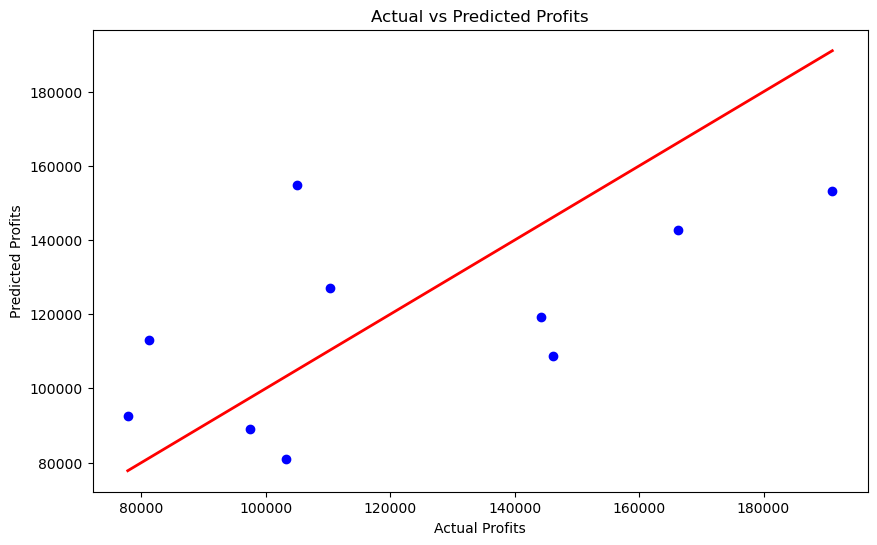

In [21]:
# Evaluating the model

# 1. Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")

# 2. Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error: {rmse:.2f}")

# 3. R-squared (R2 Score)
r2 = r2_score(y_test, y_pred)
print(f"R-squared: {r2:.2f}")

# Visualizing the Results

# Visualizing predictions vs actual values for the test set
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)
plt.title('Actual vs Predicted Profits')
plt.xlabel('Actual Profits')
plt.ylabel('Predicted Profits')
plt.show()



#### Model 3 - Product 3 and Product 1 are taken as Input. Profit is taken as output

In [22]:

X2 = df02.iloc[:, 0:-1:2].values
y2 = df02.iloc[:, 4].values

print(X2)


[[165349.2  471784.1 ]
 [162597.7  443898.53]
 [153441.51 407934.54]
 [144372.41 383199.62]
 [142107.34 366168.42]
 [131876.9  362861.36]
 [134615.46 127716.82]
 [130298.13 323876.68]
 [120542.52 311613.29]
 [123334.88 304981.62]
 [101913.08 229160.95]
 [100671.96 249744.55]
 [ 93863.75 249839.44]
 [ 91992.39 252664.93]
 [119943.24 256512.92]
 [114523.61 261776.23]
 [ 78013.11 264346.06]
 [ 94657.16 282574.31]
 [ 91749.16 294919.57]
 [ 86419.7       0.  ]
 [ 76253.86 298664.47]
 [ 78389.47 299737.29]
 [ 73994.56 303319.26]
 [ 67532.53 304768.73]
 [ 77044.01 140574.81]
 [ 64664.71 137962.62]
 [ 75328.87 134050.07]
 [ 72107.6  353183.81]
 [ 66051.52 118148.2 ]
 [ 65605.48 107138.38]
 [ 61994.48  91131.24]
 [ 61136.38  88218.23]
 [ 63408.86  46085.25]
 [ 55493.95 214634.81]
 [ 46426.07 210797.67]
 [ 46014.02 205517.64]
 [ 28663.76 201126.82]
 [ 44069.95 197029.42]
 [ 20229.59 185265.1 ]
 [ 38558.51 174999.3 ]
 [ 28754.33 172795.67]
 [ 27892.92 164470.71]
 [ 23640.93 148001.11]
 [ 15505.73

In [23]:
X2 = np.nan_to_num(X2)
y2 = np.nan_to_num(y2)
X2 = X2.astype(float)
y2 = y2.astype(float)


In [24]:
# Splitting the dataset into the Training set and Test set

X_train, X_test, y_train, y_test = train_test_split(X2, y2, test_size=0.2, random_state=0)

In [25]:
from sklearn.linear_model import LinearRegression

# Creating the regressor and fitting it to the training data
regressor = LinearRegression()
regressor.fit(X_train, y_train)

# Predicting the Test set results

y_pred = regressor.predict(X_test)



# Building the optimal model using Backward Elimination

import statsmodels.api as sm  # Updated import statement for statsmodels

# Adding a column of ones for the intercept term
X2 = np.append(arr=np.ones((50, 1)).astype(int), values=X2, axis=1)

print(X2)

# Stepwise backward elimination - OLS - Ordinary Least Squares
X_opt = X2[:, [0, 1, 2]]
regressor_OLS = sm.OLS(endog=y, exog=X_opt).fit()
regressor_OLS.summary()
print(X_opt)

X_opt = X2[:, [0, 1]]
regressor_OLS = sm.OLS(endog=y, exog=X_opt).fit()
regressor_OLS.summary()


[[1.0000000e+00 1.6534920e+05 4.7178410e+05]
 [1.0000000e+00 1.6259770e+05 4.4389853e+05]
 [1.0000000e+00 1.5344151e+05 4.0793454e+05]
 [1.0000000e+00 1.4437241e+05 3.8319962e+05]
 [1.0000000e+00 1.4210734e+05 3.6616842e+05]
 [1.0000000e+00 1.3187690e+05 3.6286136e+05]
 [1.0000000e+00 1.3461546e+05 1.2771682e+05]
 [1.0000000e+00 1.3029813e+05 3.2387668e+05]
 [1.0000000e+00 1.2054252e+05 3.1161329e+05]
 [1.0000000e+00 1.2333488e+05 3.0498162e+05]
 [1.0000000e+00 1.0191308e+05 2.2916095e+05]
 [1.0000000e+00 1.0067196e+05 2.4974455e+05]
 [1.0000000e+00 9.3863750e+04 2.4983944e+05]
 [1.0000000e+00 9.1992390e+04 2.5266493e+05]
 [1.0000000e+00 1.1994324e+05 2.5651292e+05]
 [1.0000000e+00 1.1452361e+05 2.6177623e+05]
 [1.0000000e+00 7.8013110e+04 2.6434606e+05]
 [1.0000000e+00 9.4657160e+04 2.8257431e+05]
 [1.0000000e+00 9.1749160e+04 2.9491957e+05]
 [1.0000000e+00 8.6419700e+04 0.0000000e+00]
 [1.0000000e+00 7.6253860e+04 2.9866447e+05]
 [1.0000000e+00 7.8389470e+04 2.9973729e+05]
 [1.000000

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.947
Model:                            OLS   Adj. R-squared:                  0.945
Method:                 Least Squares   F-statistic:                     849.8
Date:                Wed, 27 Aug 2025   Prob (F-statistic):           3.50e-32
Time:                        18:10:59   Log-Likelihood:                -527.44
No. Observations:                  50   AIC:                             1059.
Df Residuals:                      48   BIC:                             1063.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       4.903e+04   2537.897     19.320      0.000    4.39e+04    5.41e+04
x1             0.8543      0.029     29.151      0.000       0.795       0.913
==============================================================================
Omnibus:                       13.727   Durbin-Watson:                   1.116
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               18.536
Skew:                          -0.911   Prob(JB):                     9.44e-05
Kurtosis:                       5.361   Cond. No.                     1.65e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.65e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Mean Squared Error: 67220275.38
Root Mean Squared Error: 8198.80
R-squared: 0.95


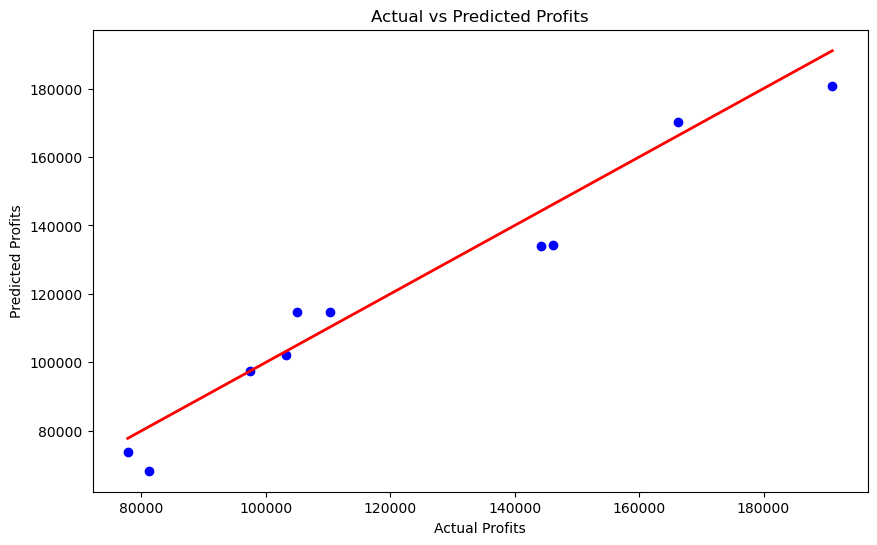

In [26]:
# Evaluating the model

# 1. Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")

# 2. Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error: {rmse:.2f}")

# 3. R-squared (R2 Score)
r2 = r2_score(y_test, y_pred)
print(f"R-squared: {r2:.2f}")

# Visualizing the Results

# Visualizing predictions vs actual values for the test set
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linewidth=2)
plt.title('Actual vs Predicted Profits')
plt.xlabel('Actual Profits')
plt.ylabel('Predicted Profits')
plt.show()



# Polynomial Regression: When Linear Lines Aren't Enough

Sometimes relationships in data aren't perfectly straight lines. I'm exploring **polynomial regression** to capture more complex, curved relationships between variables.

This notebook compares how well different approaches fit a salary vs. position level dataset where a simple linear relationship clearly won't capture the pattern.

**What I'm exploring:**
- Comparing linear regression vs. polynomial regression on the same data
- Testing different polynomial degrees (2, 3, and 4) to see their effects
- Visualizing how the fit changes as we increase model complexity
- Understanding when to use polynomial features for better predictions
- Making predictions with the best-fitting model

**Key insight I'm investigating:** When data has curved patterns, polynomial regression can transform features to capture non-linear relationships while still using linear regression under the hood.

This helps me understand when and how to move beyond simple linear models!

In [27]:
df03 = pd.read_csv(r'C:\Users\tm0792.STUDENTS.008\OneDrive - UNT System\Academics\Second Sem\DTSC 5505 - Applied ML for Data Scientists\Data_Science-Projects\ml-algos\data\Polynomial-Dataset.csv')
df03.head()

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


In [28]:
df03.describe()

,Level,Salary
count,10.00000,10.000000
mean,5.50000,249500.000000
std,3.02765,299373.883668
min,1.00000,45000.000000
25%,3.25000,65000.000000
50%,5.50000,130000.000000
75%,7.75000,275000.000000
max,10.00000,1000000.000000


In [29]:
# Loading values into X and Y

X = df03.iloc[:, 1:2].values
y = df03.iloc[:, 2].values

#print(X)

In [30]:
# Splitting the dataset into the Training set and Test set

#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

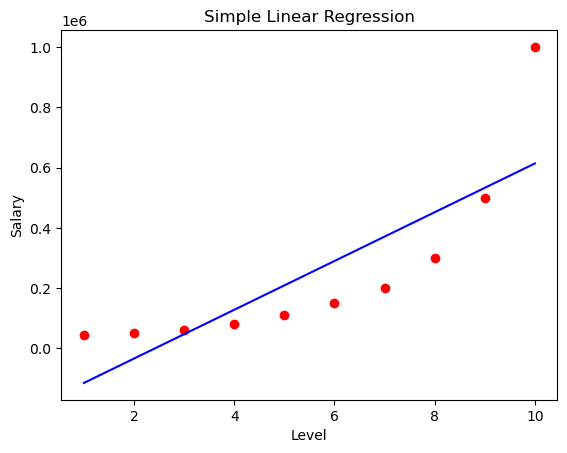

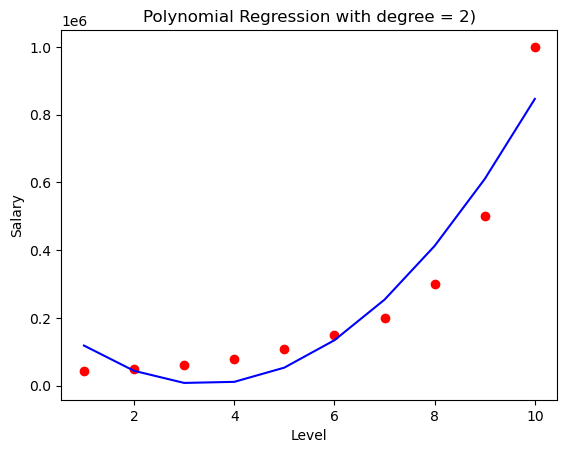

In [31]:
# Fitting Linear Regression to the dataset
from sklearn.linear_model import LinearRegression

# Creating a Linear Regression model and fitting it to the data
lin_reg = LinearRegression()
lin_reg.fit(X, y)

# Fitting Polynomial Regression to the dataset
from sklearn.preprocessing import PolynomialFeatures
poly_reg = PolynomialFeatures(degree=2)
X_poly = poly_reg.fit_transform(X)
lin_reg_2 = LinearRegression()
lin_reg_2.fit(X_poly, y)


# Visualising the Linear Regression results
plt.scatter(X, y, color='red')
plt.plot(X, lin_reg.predict(X), color='blue')
plt.title('Simple Linear Regression')
plt.xlabel('Level')
plt.ylabel('Salary')
plt.show()

# Visualising the Polynomial Regression results
plt.scatter(X, y, color='red')
plt.plot(X, lin_reg_2.predict(poly_reg.fit_transform(X)), color='blue')
plt.title('Polynomial Regression with degree = 2)')
plt.xlabel('Level')
plt.ylabel('Salary')
plt.show()



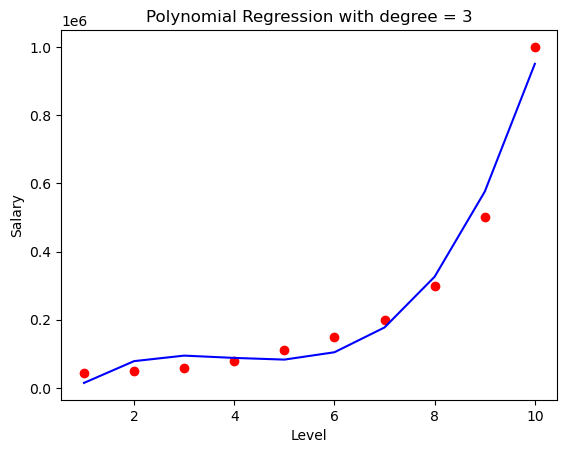

In [32]:
# Fitting Polynomial Regression to the dataset with degree=3
poly_reg = PolynomialFeatures(degree=3)
X_poly = poly_reg.fit_transform(X)
lin_reg_3 = LinearRegression()
lin_reg_3.fit(X_poly, y)

# Visualising the Polynomial Regression results with degree=3
plt.scatter(X, y, color='red')
plt.plot(X, lin_reg_3.predict(poly_reg.fit_transform(X)), color='blue')
plt.title('Polynomial Regression with degree = 3')
plt.xlabel('Level')
plt.ylabel('Salary')
plt.show()

C:\Users\tm0792.STUDENTS.008\AppData\Local\Temp\ipykernel_12656\898822240.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.1)


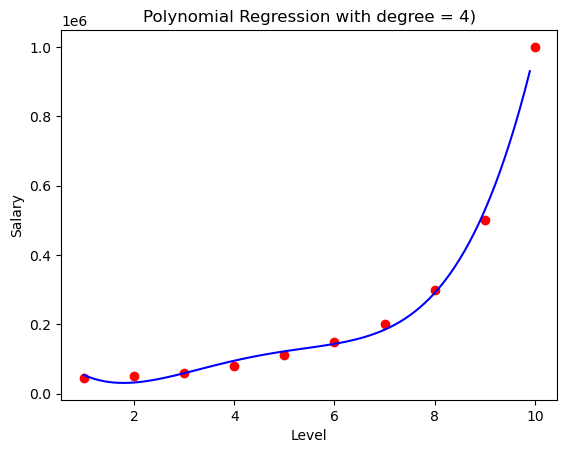

In [33]:
# Fitting Polynomial Regression to the dataset with degree=4
poly_reg = PolynomialFeatures(degree=4)
X_poly = poly_reg.fit_transform(X)
lin_reg_4 = LinearRegression()
lin_reg_4.fit(X_poly, y)

# Visualising the Polynomial Regression results with degree=4
X_grid = np.arange(min(X), max(X), 0.1)
X_grid = X_grid.reshape((len(X_grid), 1))
plt.scatter(X, y, color='red')
plt.plot(X_grid, lin_reg_4.predict(poly_reg.fit_transform(X_grid)), color='blue')
plt.title('Polynomial Regression with degree = 4)')
plt.xlabel('Level')
plt.ylabel('Salary')
plt.show()

In [34]:
# Predicting a new result with Polynomial Regression (degree=4)
predicted_value = lin_reg_4.predict(poly_reg.fit_transform([[6.5]]))
print(f"Predicted salary for position 6.5: {predicted_value[0]}")


Predicted salary for position 6.5: 158862.45265152678
